### In this notebook, several different customer churn prediction models will be developed based on a customer database from a telecommunications company. Different machine learning algorithms will be used.

## Exploratory Data Analysis and Feature Engineering

In [ ]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
# Let's check the number of rows and columns
df.shape

(7043, 21)

In [ ]:
# We have got records for 7043 customers.
# There are 21 features including the target variable "Churn".
# No date is provided in this dataset. Only tenure (number of months the customer has stayed within the company) can be used as a proxy for time.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# We can see that the "TotalCharges column is object type, but it should be numeric. Let's check it out."
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [7]:
# Let's change the type of "TotalCharges" column to numeric, and force errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
# Let's double check the type of "TotalCharges" column after conversion
df["TotalCharges"].dtypes

dtype('float64')

In [9]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

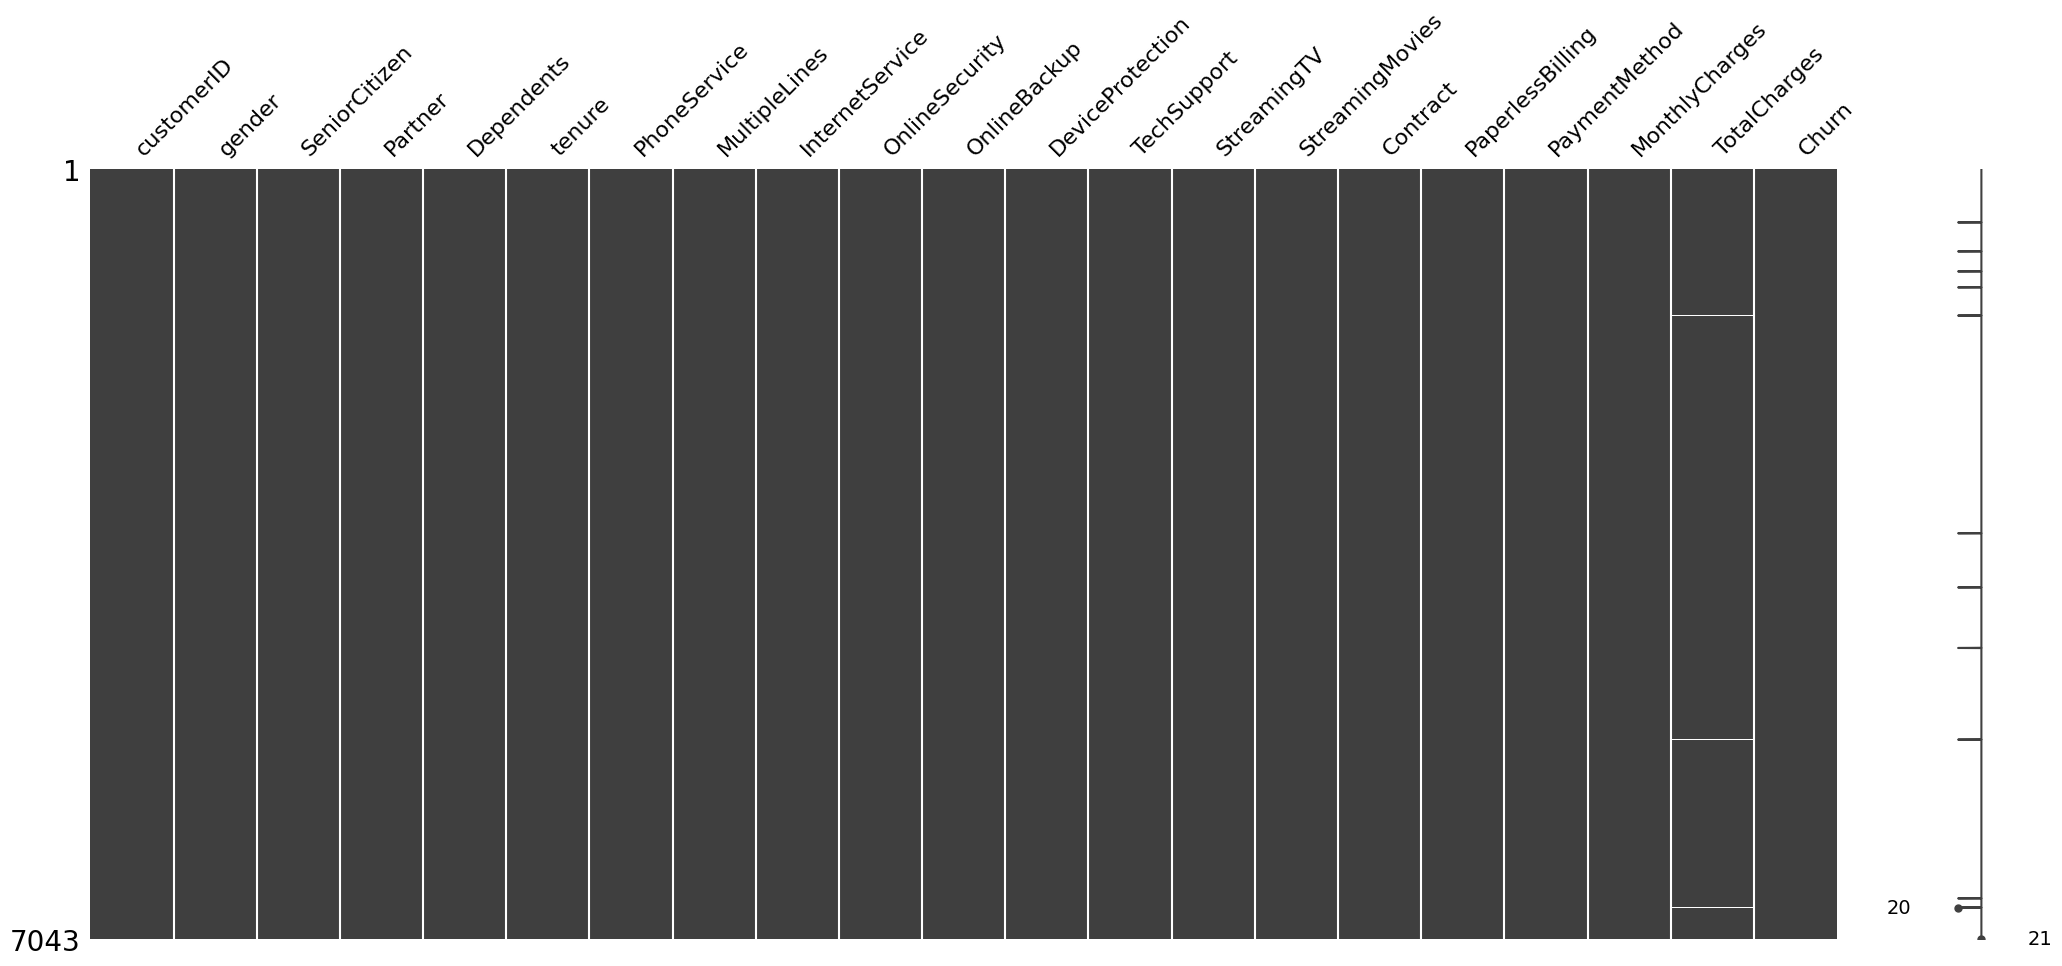

In [10]:
# Visualize missing values as a matrix
msno.matrix(df, figsize=(25, 10));

In [11]:
# There are some missing values in the "TotalCharges" column. Let's view them.
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


It seems that the reason why some rows have empty "TotalCharges" values is that these customers have recently become a subscriber. Therefore, their "Churn" status is marked with "No" and since this would not help model to achieve better results, we will remove these instances.

In [12]:
# Let's remove the empty values in the "TotalCharges" column
df.dropna(subset=['TotalCharges'], inplace=True)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [13]:
# We will not use "customerID" column for model building, so let's drop it.
df = df.drop(columns=['customerID'])
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [14]:
# Let's see how many missing values we have now
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
# Let's map the "SeniorCitizen" column to "Yes" and "No"
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})
df["SeniorCitizen"].unique()

array(['No', 'Yes'], dtype=object)

In [16]:
# Let's see the details of numerical features
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


### Data Visualisation

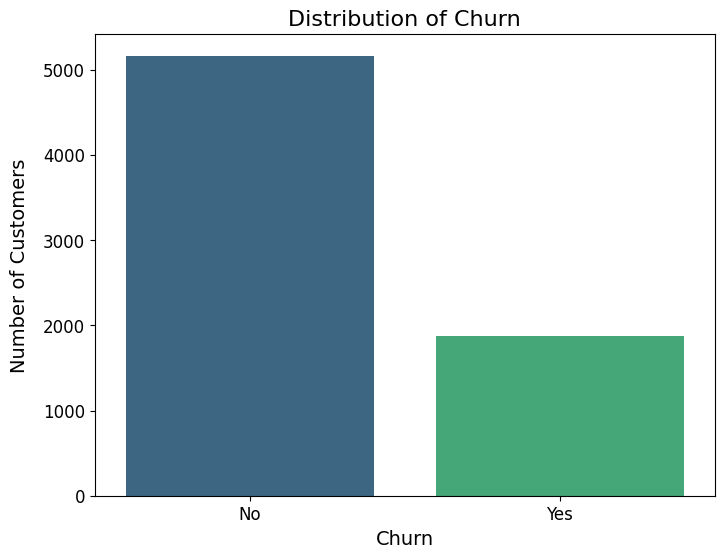

In [65]:
# Let's visualize the distribution of the target variable "Churn" with matplotlib

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribution of Churn', fontsize=16)
plt.xlabel('Churn', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14, labelpad=10)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

This dataset is slightly imbalanced with approximately 26.5% of customers who churned and 73.5% who did not.
Accuracy alone may not be a sufficient metric for evaluating model performance in this case.
Metrics like ROC & AUC, precision/recall, F1-score will provide a more comprehensive understanding of the model's effectiveness in predicting churn.

For the high-level feature understanding, let's take a look at the following:
* Customer profile
* Account / Relationship
* Services
* Charges

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

### Customer Profile Analysis

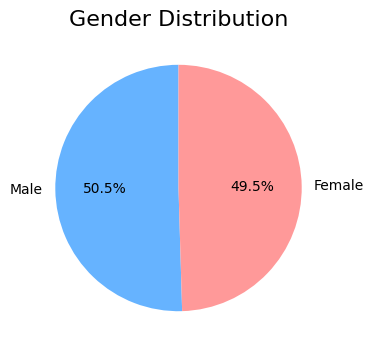

In [167]:
# Gender distribution
gender_counts = df['gender'].value_counts()
plt.figure(figsize=(6, 4))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Gender Distribution', fontsize=16)
plt.show()

# This dataset has a roughly balanced distribution of genders.

In [168]:
# Let's create a combined DataFrame to see the counts of churn by gender
gender_churn_counts = df.groupby(['Churn', 'gender']).size().reset_index(name='counts')

In [169]:
gender_churn_counts

,Churn,gender,counts
0,No,Female,2544
1,No,Male,2619
2,Yes,Female,939
3,Yes,Male,930


In [170]:
# Combine labels for Churn and Gender
gender_churn_counts['label'] = gender_churn_counts['Churn'] + ' - ' + gender_churn_counts['gender']

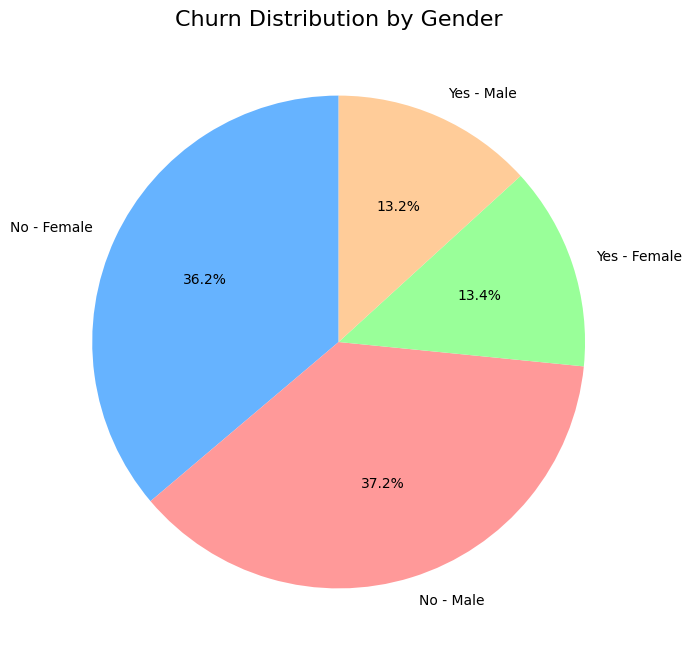

In [178]:
# Pie chart for Churn distribution among genders
plt.figure(figsize=(8, 8))
plt.pie(gender_churn_counts['counts'], labels=gender_churn_counts['label'], autopct='%1.1f%%', 
        startangle=90, colors=['#66b3ff', '#ff9999', '#99ff99', '#ffcc99'])
plt.title('Churn Distribution by Gender', fontsize=16)
plt.show()

No significant impact of gender to churn is observed.

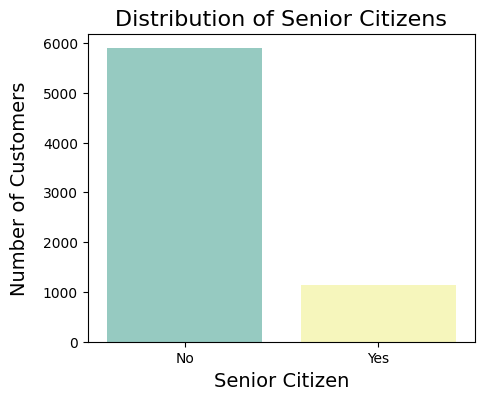

In [ ]:
# Senior Citizen Distribution
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='SeniorCitizen', palette='Set3')
plt.title('Distribution of Senior Citizens', fontsize=16)
plt.xlabel('Senior Citizen', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14, labelpad=10)
plt.show()

The customer base consists of a smaller proportion of senior citizens compared to non-senior citizens.

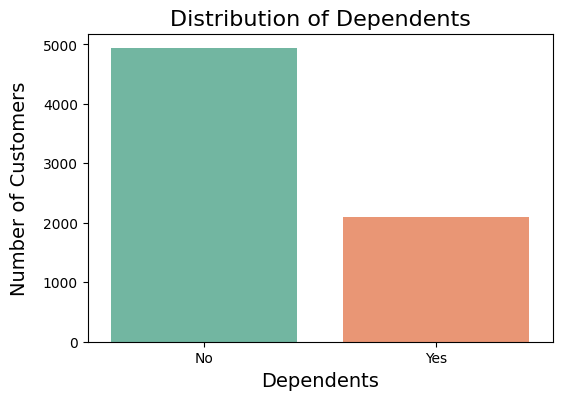

In [190]:
# Dependent Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Dependents', palette='Set2')
plt.title('Distribution of Dependents', fontsize=16)
plt.xlabel('Dependents', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14, labelpad=10)
plt.show()

In [183]:
# Let's see the churn rates among costumers with and without dependents
dependents_churn_counts = df.groupby(['Churn', 'Dependents']).size().reset_index(name='counts')
dependents_churn_counts

,Churn,Dependents,counts
0,No,No,3390
1,No,Yes,1773
2,Yes,No,1543
3,Yes,Yes,326


In [188]:
# Combine labels for Churn and Dependents
dependents_churn_counts['label'] = ' Churn:' + dependents_churn_counts['Churn'] + ' - Dependents:' + dependents_churn_counts['Dependents']

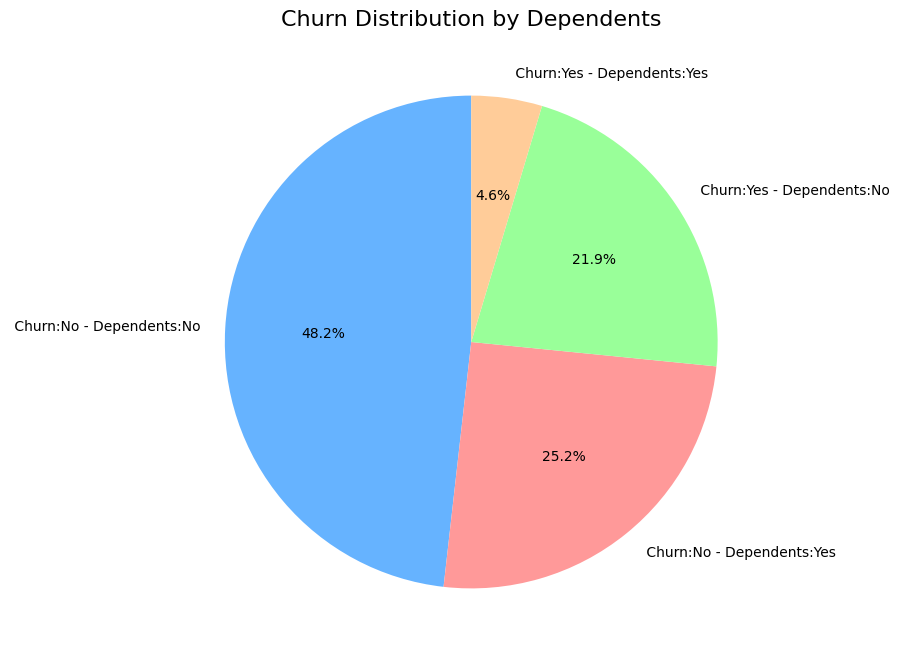

In [189]:
# Pie chart for Churn distribution by dependents
plt.figure(figsize=(8, 8))
plt.pie(dependents_churn_counts['counts'], labels=dependents_churn_counts['label'], autopct='%1.1f%%', 
        startangle=90, colors=['#66b3ff', '#ff9999', '#99ff99', '#ffcc99'])
plt.title('Churn Distribution by Dependents', fontsize=16)
plt.show()

In [ ]:
# Let's take a closer look at customers who churned and whether they have dependents or not
dependents_churned = dependents_churn_counts[dependents_churn_counts['Churn'] == 'Yes']
dependents_churned.drop(columns=['label'], inplace=True)
dependents_churned['label'] = 'Depenedents:' + dependents_churned['Dependents']

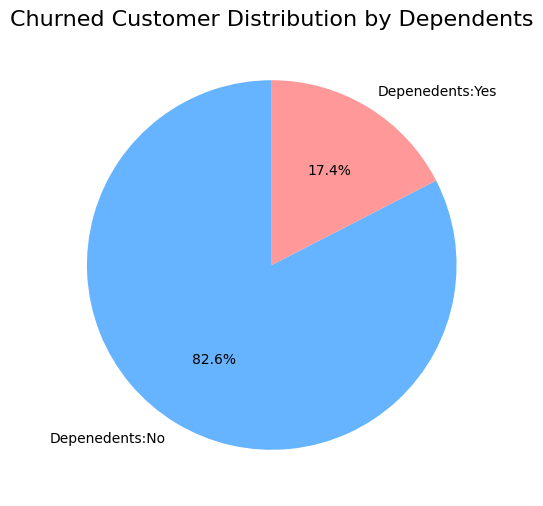

In [202]:
# Let's visualize the distribution with a pie chart
plt.figure(figsize=(6, 6))
plt.pie(dependents_churned['counts'], labels=dependents_churned['label'], autopct='%1.1f%%', 
        startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Churned Customer Distribution by Dependents', fontsize=16)
plt.show()

Among the ones who churned, we can see that almost 83% of them do not have any dependents.

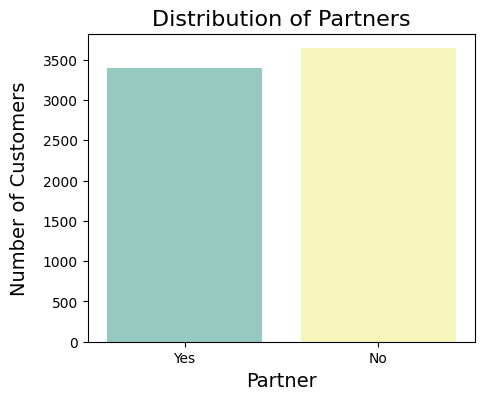

In [ ]:
# Partner Distribution
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Partner', palette='Set3')
plt.title('Distribution of Partners', fontsize=16)
plt.xlabel('Partner', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14, labelpad=10)
plt.show()

# Balanced distribution between partners and non-partners.

In [154]:
df['Partner'].value_counts()

Partner
No     3639
Yes    3393
Name: count, dtype: int64

In [127]:
df['PhoneService'].value_counts()
df['InternetService'].value_counts()
df['OnlineSecurity'].value_counts()
df.describe(include=[object])

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3549,5890,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


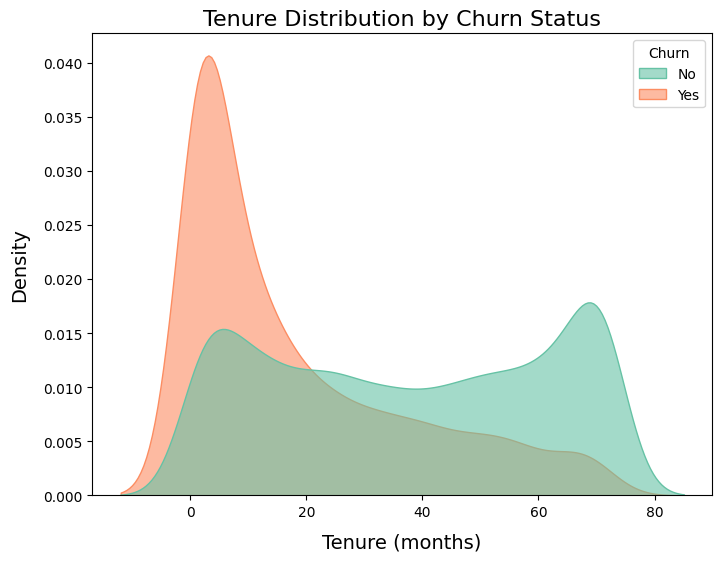

In [76]:
# Let's make a KDE (Kernel Density Estimation) plot for the "tenure" feature
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='Set2', alpha=0.6)
plt.title('Tenure Distribution by Churn Status', fontsize=16)
plt.xlabel('Tenure (months)', fontsize=14, labelpad=10)
plt.ylabel('Density', fontsize=14, labelpad=10)
plt.show()

We can see that customers with lower tenure are more likely to churn.
For the customers that did not leave the service, the distribution is more spread out, indicating that they have been with the service for a longer period.
This suggests that tenure is an important factor in customer churn, with newer customers being at a higher risk of leaving the service.

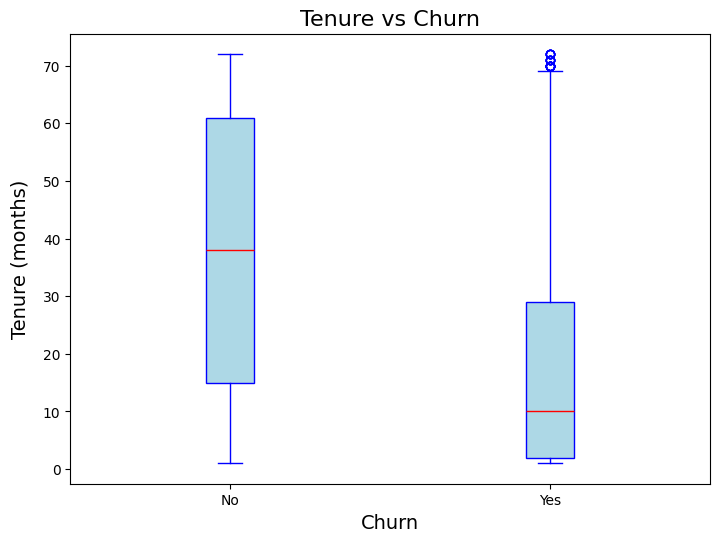

In [120]:
# Let's take a look at "Tenure vs Churn" using boxplot
df.boxplot(column='tenure', by='Churn', grid=False, figsize=(8, 6), patch_artist=True,
              boxprops=dict(facecolor='lightblue', color='blue'),
                medianprops=dict(color='red'),
                whiskerprops=dict(color='blue'),
                capprops=dict(color='blue'),
                flierprops=dict(color='blue', markeredgecolor='blue'))
plt.title('Tenure vs Churn', fontsize=16)
plt.suptitle('')
plt.xlabel('Churn', fontsize=14)
plt.ylabel('Tenure (months)', fontsize=14, labelpad=10)
plt.show()

Customers who churned have a median tenure of around 10 months, they are mostly short-term customers.
Customers who did not churn have a median tenure of around 38 months, they have much longer customer lifetime.

From the above statement, we can conclude that early life churn is a critical risk.
Retention efforts should be focused on customers within their first year.

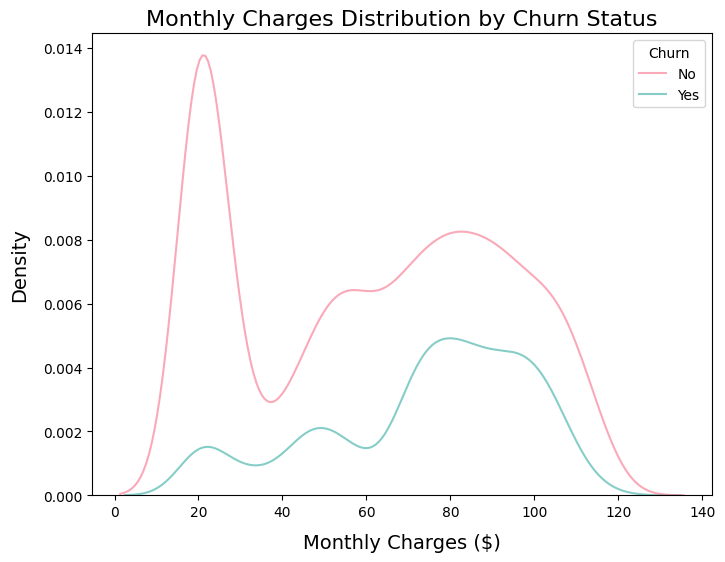

In [113]:
# Let's make a KDE plot for the "MonthlyCharges" feature
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=False, common_norm=True, palette='husl', alpha=0.6)
plt.title('Monthly Charges Distribution by Churn Status', fontsize=16)
plt.xlabel('Monthly Charges ($)', fontsize=14, labelpad=10)
plt.ylabel('Density', fontsize=14, labelpad=10)
plt.show()

# The KDE plot for "MonthlyCharges" shows that customers who churn tend to have higher monthly charges compared to those who stay.
# This indicates that higher monthly costs may be a significant factor contributing to customer churn.

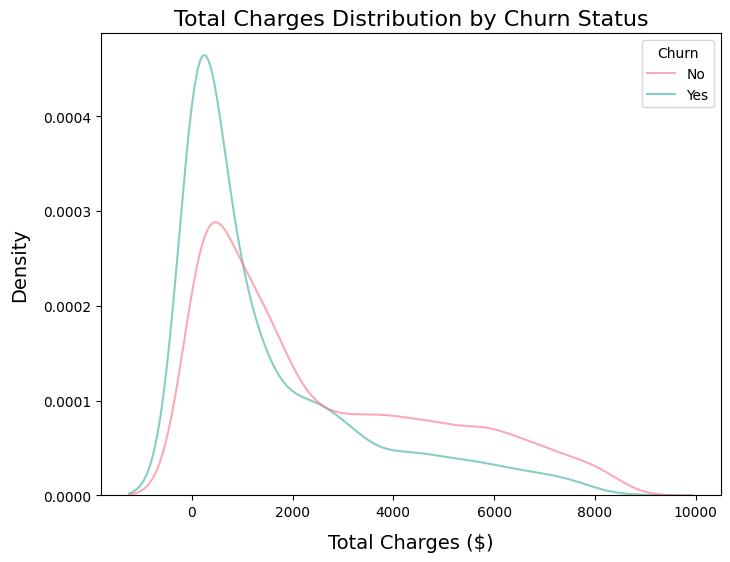

In [ ]:
# Let's make a KDE plot for "TotalCharges" feature
plt.figure(figsize=(8, 6))
sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=False, common_norm=False, palette='husl', alpha=0.6) # Common_norm=True to compare overall distribution
plt.title('Total Charges Distribution by Churn Status', fontsize=16)
plt.xlabel('Total Charges ($)', fontsize=14, labelpad=10)
plt.ylabel('Density', fontsize=14, labelpad=10)
plt.show()

The KDE plot for "TotalCharges" indicates that customers who have lower total charges are more likely to churn.
This suggests that customers who have not been with the company for a long time (and thus have lower total charges) are at a higher risk of leaving the service.
Conversely, customers with higher total charges, indicating longer tenure, are less likely to churn.

In [116]:
# Let's see the details of categorical features
df.describe(include=['object'])

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3549,5890,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


When developing the model, we might consider removing the customers with low tenure and no churn, as they may not help model training since they have not had enough time to exhibit churn behavior.

## Attribution

This notebook was created as part of an churn prediction project. The following resources and tools were used:

- **Dataset**: Telcom Customer Churn dataset (https://www.kaggle.com/code/bhartiprasad17/customer-churn-prediction/input)
- **Reference Project**: This work was inspired by the Kaggle project "CUSTOMER CHURN PREDICTION 📈 https://www.kaggle.com/code/bhartiprasad17/customer-churn-prediction/notebook".